# Toxicity Fairness Analysis with Zero-Shot LLMs and Integrated Gradients

Zero-shot toxicity classification with Integrated Gradients explanations and fairness analysis across demographic identity groups for Responsible AI evaluation.

## Pipeline Overview
- Zero-shot toxicity/hate/offense classification using LLMs
- Integrated Gradients (IG) token attribution explanations
- Token-level attribution heatmap visualization
- Fairness metrics computation across demographic groups
- Dataset downloading utilities for social bias benchmarks

## Features
- Log-probability-based zero-shot classification (no fine-tuning required)
- Integrated Gradients for model interpretability
- Group fairness metrics (SPD, Equal Opportunity, worst-case)
- Multi-dataset support (Jigsaw, CivilComments, SBIC, HateXplain)
- Resume-safe Parquet/CSV I/O
- GPU/CPU automatic device selection
<!-- ## File Overview
| File | Purpose |
|------|---------|
| `llm_zero_shot_explain.py` | Core zero-shot classification engine with Integrated Gradients explanations. |
| `fairness_metrics.py` | Computes per-group fairness metrics (Accuracy, F1, TPR, FPR, SPD, EOpp). |
| `download_data.py` | Download and normalize social bias datasets from Hugging Face. |
| `sample_jigsaw.py` | Convert Kaggle Jigsaw CSV to normalized Parquet format. | -->

# Download and Normalize Social-Problem Datasets

This notebook downloads, normalizes, and saves social-problem datasets into Parquet files.

Outputs are standardized with at least:
- `comment_text`
- `target`

In [1]:
# ===== Standard library =====
import importlib.util
import itertools
import random
from collections.abc import Generator, Iterator
from pathlib import Path
from typing import Any

# ===== Scientific stack =====
import numpy as np
import numpy.typing as npt
import pandas as pd

# ===== ML / DL =====
import torch
from torch.nn import functional
from transformers import AutoModelForCausalLM, AutoTokenizer

# ===== Datasets & metrics =====
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

# ===== Visualization & progress =====
import matplotlib.pyplot as plt
from rich.progress import track


/fs01/projects/aixpert/users/aravind/interpretability_agent_bootcamp/implementations/toxicity_fairness_analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from src.download_data import (
    load_civil,
    to_parquet  
)

In [3]:
# Configuration (edit interactively)
DATASET = "civil"
STREAM = True
TAKE = 100000 # for full data = 100000, 5_000
SAMPLE = None
DATA_DIR = f"./data/{DATASET}/"
OUT_PATH = f"./data/{DATASET}/{DATASET}.parquet"


## Data Formats

### Input Datasets
Supported datasets via `download_data.py`:
- **CivilComments**: Toxicity labels with 7 toxicity sub-types

Expected columns:
```json
{
  "comment_text": "Text content to classify",
  "target": 0 or 1,  // binary toxicity label
  "severe_toxicity": 0.0-1.0,   // identity attribute scores
  "obscene": 0.0-1.0,
  "insult": 0.0-1.0,
  "thread": 0.0-1.0,
  // ... additional identity columns
}
```

In [4]:
df = load_civil(stream=STREAM, take=TAKE)

if SAMPLE and len(df) > SAMPLE:
    df = df.sample(SAMPLE, random_state=42).reset_index(drop=True)

df.head()

,comment_text,target,severe_toxicity,obscene,identity_attack,insult,threat
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.0,0.000000,0.00000,0.0
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.0,0.000000,0.00000,0.0
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.0,0.000000,0.00000,0.0
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.0,0.000000,0.00000,0.0
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.0,0.021277,0.87234,0.0


In [5]:
to_parquet(df, OUT_PATH)

Wrote 100,000 rows -> data/civil/civil.parquet


# Zero-shot LLM Toxicity Scoring with Integrated Gradients

This notebook performs zero-shot binary classification on social-problem text
(e.g. toxicity, hate, offense) using a causal LLM, and computes
Integrated Gradients (IG) explanations over prompt tokens.

Key features:
- Zero-shot scoring via log-probability differences
- Integrated Gradients using `inputs_embeds`
- Optional float32 stability for LayerNorm
- Parquet/CSV-safe data loading

In [6]:
from src.llm_zero_shot_explain import (
    get_device,
    load_llm,
    format_prompt,
    label_logprob,
    score_and_predict,
    integrated_gradients,
    save_heatmap,
    load_df_safely,
)

In [7]:
LABELS = {
    "toxicity": ["toxic", "non-toxic"],
    "hate": ["hateful", "not hateful"],
    "offense": ["offensive", "not offensive"],
}

In [10]:
# ---- User configuration ----
# DATASET = "civil"
# DATA_DIR = f"./data/{DATASET}/"
INPUT_PATH = f"./data/{DATASET}/{DATASET}.parquet"
TEXT_COL = "comment_text"
TASK = "toxicity"
MODEL_NAME = "distilgpt2"

MAX_ROWS = 1000
IG_ROWS = 25
IG_STEPS = 32
FORCE_FLOAT32 = True
SAVE_HEATMAPS = True

OUTPUT_PATH = f"./results/{DATASET}/zs_preds.parquet"


In [ ]:
df = load_df_safely(INPUT_PATH)
df = df.iloc[:MAX_ROWS].copy()

device = get_device()
model, tok = load_llm(MODEL_NAME, device, force_float32=FORCE_FLOAT32)

preds = []
ig_records = []

for i in track(range(len(df)), description="Scoring"):
    text = str(df.iloc[i][TEXT_COL])[:4096]
    res = score_and_predict(model, tok, text, TASK)

    preds.append({
        "idx": i,
        "pred": res["pred"],
        "score": res["score"],
        "lp_pos": res["lp_pos"],
        "lp_neg": res["lp_neg"],
    })

    if SAVE_HEATMAPS and len(ig_records) < IG_ROWS:
        toks, atts, prompt = integrated_gradients(
            model, tok, text, TASK, steps=IG_STEPS
        )
        img_path = Path(f"./results/{DATASET}/ig_heatmaps") / f"row{i}.png"
        save_heatmap(toks, atts, str(img_path))
        ig_records.append({"idx": i, "heatmap": str(img_path), "prompt": prompt})


In [12]:
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(preds).to_parquet(OUTPUT_PATH, index=False)

if ig_records:
    pd.DataFrame(ig_records).to_parquet(
        Path(OUTPUT_PATH).with_suffix(".ig.parquet"),
        index=False,
    )

print(f"Saved predictions -> {OUTPUT_PATH}")

Saved predictions -> ./results/civil/zs_preds.parquet


# Fairness Metrics Across Demographic Groups

In [13]:
from src.fairness_metrics import (
    load_df,
    binarize_labels,
    metrics_for_group,
)

In [14]:
df = pd.read_parquet(f"./results/{DATASET}/zs_preds.parquet")
print(df.columns.tolist())


['idx', 'pred', 'score', 'lp_pos', 'lp_neg']


In [15]:
# ===== CONFIG =====
PREDS_PATH = f"./results/{DATASET}/zs_preds.parquet"
LABELS_FILE = f"./data/{DATASET}/{DATASET}.parquet"
LABEL_COL = "target"
POSITIVE_LABEL = 1


IDENTITY_COLS = [
    "severe_toxicity",
    "obscene",
    "identity_attack",
    "insult",
    "threat",
]

MIN_GROUP_SIZE = 30
OUTPUT_PATH = f"./results/{DATASET}/fairness_report.csv"

In [16]:
df_preds = load_df(PREDS_PATH)

if "idx" not in df_preds.columns:
    raise ValueError("Predictions must contain 'idx' column.")

if LABELS_FILE:
    df_labels = load_df(LABELS_FILE)
    if "idx" not in df_labels.columns:
        df_labels = df_labels.reset_index().rename(columns={"index": "idx"})
    df = df_preds.merge(df_labels, on="idx", how="left")
else:
    df = df_preds.copy()

if LABEL_COL not in df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found.")


In [17]:
y_true = binarize_labels(
    df[LABEL_COL],
    positive_label=POSITIVE_LABEL,
    threshold=0.5,
)

if "pred" not in df.columns:
    raise ValueError("Missing 'pred' column in predictions.")

y_pred = df["pred"].astype(int).values


In [18]:
rows = []
per_identity = []

for identity in IDENTITY_COLS:
    if identity not in df.columns:
        print(f"[warn] identity column '{identity}' missing; skipping")
        continue

    membership = (
        (pd.to_numeric(df[identity], errors="coerce").fillna(0) > 0)
        .astype(int)
        .values
    )

    group_rows = []

    for val in (0, 1):
        mask = membership == val
        n = int(mask.sum())

        if n < MIN_GROUP_SIZE:
            group_rows.append(
                {
                    "identity": identity,
                    "group": f"{identity}={val}",
                    "n": n,
                    "skipped": True,
                }
            )
            continue

        metrics = metrics_for_group(y_true[mask], y_pred[mask])
        group_rows.append(
            {
                "identity": identity,
                "group": f"{identity}={val}",
                "n": n,
                "skipped": False,
                **metrics,
            }
        )

    g0 = next((r for r in group_rows if r["group"].endswith("=0") and not r["skipped"]), None)
    g1 = next((r for r in group_rows if r["group"].endswith("=1") and not r["skipped"]), None)

    if g0 and g1:
        per_identity.append(
            {
                "identity": identity,
                "SPD": g1["pos_rate"] - g0["pos_rate"],
                "EOpp_diff": g1["tpr"] - g0["tpr"],
                "n_A0": g0["n"],
                "n_A1": g1["n"],
            }
        )

    rows.extend(group_rows)


In [19]:
rep = pd.DataFrame(rows)
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
rep.to_csv(OUTPUT_PATH, index=False)

if per_identity:
    pi = pd.DataFrame(per_identity)
    pi.to_csv(Path(OUTPUT_PATH).with_suffix(".per_identity.csv"), index=False)

    summary = pd.DataFrame(
        [{
            "WorstAbsSPD": pi["SPD"].abs().max(),
            "WorstAbsEOpp": pi["EOpp_diff"].abs().max(),
            "WorstGroupAcc": rep.loc[~rep["skipped"], "acc"].min(),
            "WorstGroupF1": rep.loc[~rep["skipped"], "f1"].min(),
        }]
    )
else:
    summary = pd.DataFrame(
        [{
            "WorstAbsSPD": np.nan,
            "WorstAbsEOpp": np.nan,
            "WorstGroupAcc": np.nan,
            "WorstGroupF1": np.nan,
        }]
    )

summary.to_csv(Path(OUTPUT_PATH).with_suffix(".summary.csv"), index=False)

print("Saved:")
print(" - Per-group metrics:", OUTPUT_PATH)
print(" - Per-identity disparities:", Path(OUTPUT_PATH).with_suffix(".per_identity.csv"))
print(" - Summary:", Path(OUTPUT_PATH).with_suffix(".summary.csv"))


Saved:
 - Per-group metrics: ./results/civil/fairness_report.csv
 - Per-identity disparities: results/civil/fairness_report.per_identity.csv
 - Summary: results/civil/fairness_report.summary.csv


# Stage 4 — Visualize Fairness Results

In this stage, we analyze whether the **zero-shot LLM toxicity classifier** exhibits systematic disparities across different **toxicity subtypes** present in the CivilComments dataset.

Rather than demographic identities (e.g., gender or religion), CivilComments provides **content-based subgroup labels** such as *insult*, *threat*, and *identity attack*. These can be treated as binary group indicators to evaluate fairness across different forms of toxic content.


## ⚖️ Fairness Metrics Used

We compute standard **group fairness metrics** by comparing model behavior between:

* **A = 1**: comments where a given subtype label is present
* **A = 0**: comments where that subtype label is absent

The key metrics are:

**Statistical Parity Difference (SPD)**

$$
\text{SPD} = P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0)
$$

Measures whether the model predicts *toxicity* more often for one group than another.


**Equal Opportunity Difference (EOpp)**

$$
\text{EOpp} = \text{TPR}_{A=1} - \text{TPR}_{A=0}
$$

  Measures whether true toxic comments are detected equally well across groups.

**Worst-case metrics**

  We also report the worst (minimum) accuracy and F1 score across all groups to highlight the most disadvantaged subgroup.

In [20]:
OUTPUT_DIR = Path(f"results/{DATASET}")
SUMMARY_PATH = OUTPUT_DIR / "fairness_report.summary.csv"
PER_IDENTITY_PATH = OUTPUT_DIR / "fairness_report.per_identity.csv"

The table below summarizes the **worst observed disparities** across all toxicity subtypes:

* **WorstAbsSPD**: largest absolute statistical parity difference
* **WorstAbsEOpp**: largest absolute equal opportunity difference
* **WorstGroupAcc / WorstGroupF1**: lowest performance among all groups

These values help identify whether *any* subgroup experiences disproportionately poor or biased treatment.

In [21]:
summary_df = pd.read_csv(SUMMARY_PATH)
summary_df

,WorstAbsSPD,WorstAbsEOpp,WorstGroupAcc,WorstGroupF1
0,0.168268,0.186441,0.485714,0.0


## 🧩 Per-Identity (Subtype) Fairness Breakdown

For each toxicity subtype (e.g., `identity_attack`, `insult`, `threat`), we compute:

* **SPD**: difference in predicted toxicity rate
* **EOpp_diff**: difference in true positive rates
* **n_A0 / n_A1**: group sizes (absence vs presence of subtype)

This breakdown allows us to localize where disparities arise instead of relying only on aggregate statistics.


In [22]:
pi = pd.read_csv(PER_IDENTITY_PATH)
pi

,identity,SPD,EOpp_diff,n_A0,n_A1
0,severe_toxicity,0.119615,0.069378,965,35
1,obscene,0.077860,0.027778,938,62
2,identity_attack,0.168268,0.151584,949,51
3,insult,0.086779,0.186441,819,181
4,threat,0.048454,-0.037643,961,39


## 📈 Visualization: Statistical Parity Difference (SPD)

The bar chart below visualizes **SPD per toxicity subtype**.

* Each bar corresponds to one subtype (e.g., *identity_attack*).
* The horizontal dashed line at 0 indicates **perfect statistical parity**.
* Positive SPD values mean the model predicts *toxicity* more often when that subtype is present.

This visualization makes it easy to identify which forms of toxic content are most strongly associated with biased predictions.

<Figure size 800x400 with 0 Axes>

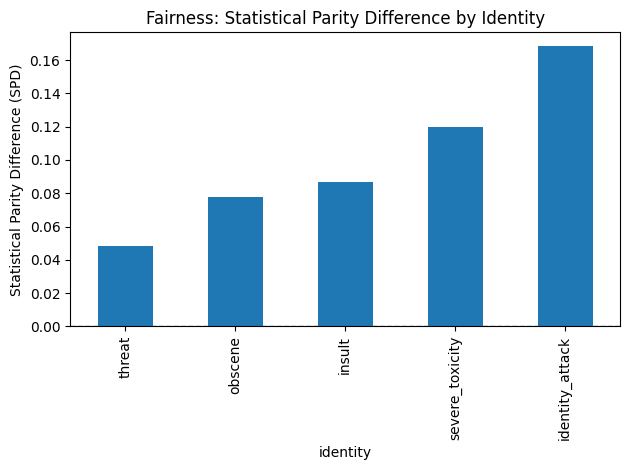

Saved -> results/civil/civil_SPD.png


In [23]:
plt.figure(figsize=(8, 4))
pi.sort_values("SPD").plot(
    x="identity",
    y="SPD",
    kind="bar",
    legend=False,
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Statistical Parity Difference (SPD)")
plt.title("Fairness: Statistical Parity Difference by Identity")
plt.tight_layout()

out_path = OUTPUT_DIR / "civil_SPD.png"
plt.savefig(out_path, dpi=200)
plt.show()

print(f"Saved -> {out_path}")

## 🧠 Interpretation and Takeaways

From the results:

* Certain subtypes (e.g., **identity_attack** and **severe_toxicity**) show noticeably higher SPD values.
* This suggests the zero-shot LLM is **more likely to flag toxicity** when these patterns are present, even controlling for the overall label.
* Such behavior may reflect:

  * Model sensitivity to strong lexical cues
  * Training data biases inherited by the language model
  * Over-generalization from certain toxic patterns

Importantly, this analysis does **not** imply intent or malice, but highlights where **model behavior differs systematically across content subgroups**.

## 🔍 Relation to Interpretability

In earlier stages, we computed **Integrated Gradients explanations** for selected examples. Combining those explanations with fairness results allows us to:

* Inspect *which tokens* drive high toxicity scores in high-SPD subgroups
* Diagnose whether explanations differ qualitatively across subtypes
* Bridge **fairness evaluation** with **model interpretability**

This closes the loop between *what the model predicts*, *how fairly it behaves*, and *why it makes those predictions*.